# Classical Policy Iteration (Tabular) on CartPole-v1

This notebook loads [config_classical_pi.yaml](config_classical_pi.yaml) and runs
`TabularPolicyIterationAgent` on `CartPole-v1` — **step 1** of the low-rank PI plan.

Policy evaluation is the classical baseline of
[LoRa-PI (Stojanovic, Jedra & Proutière, NeurIPS 2024)](https://arxiv.org/abs/2410.23434):
Q^π(s, a) is estimated for **every** (bin-centre, action) by a generative-model
Monte-Carlo rollout — teleport the env to s, force a, follow the greedy policy to
termination/horizon, accumulate the discounted return. Improvement is the greedy
argmax over the table. Step 2 will override `evaluate_policy` to sample fewer
entries / truncate rollouts and complete Q via the low-rank Hankel structure.

The env carries the tabular machinery: `discrete_config.state_bins` adds the
`DiscreteStateWrapper` (bin geometry + `discretise`, bounds from `clip.state`)
and `generative: true` adds the `GenerativeStateWrapper` (`teleport`).

## Imports

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from experiment import load_config, build_env, build_agent, train_policy_iteration, make_run_logger
from agents.policy_iteration_agent import TabularPolicyIterationAgent
from analysis.registry import resolve_methods
from analysis.low_rank.rank import row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the config file

Note the non-default filename — this experiment shares the directory with the DQN
baseline (`config.yaml`) and Rainbow (`config_rainbow.yaml`).

In [2]:
cfg = load_config("config_classical_pi.yaml")   # loads yaml, resolves device, seeds torch/numpy
print("device:", cfg["experiment"]["_device"])
cfg

device: cuda


{'experiment': {'name': 'cartpole_classical_pi',
  'seed': 52,
  'device': 'cuda',
  'save_artifacts': True,
  '_device': 'cuda'},
 'environment': {'name': 'CartPole-v1',
  'render_mode': None,
  'generative': True,
  'discrete_config': {'state_bins': [8, 8, 8, 10]},
  'normalise': {'action': {}, 'state': {}},
  'clip': {'action': False,
   'state': {'min': [-2.4, -3.0, -0.2095, -3.5],
    'max': [2.4, 3.0, 0.2095, 3.5]}}},
 'agent': {'discount_factor': 0.99, 'horizon': 500, 'n_eval_rollouts': 1},
 'training': {'no_iterations': 100,
  'eval_episodes_per_iter': 5,
  'solved_reward': 475},
 'analysis': {'ep_freq': 1,
  'methods': [{'name': 'q_matrix_tabular', 'outputs': ['Q-table']}],
  'hankel_sweep': {'enabled': True,
   'n_rollouts': 10,
   'base_seed': 52,
   'functions': ['Hankel Q', 'Hankel V'],
   'save_trajectories': True,
   'sub_trajectory': {'enabled': False,
    'min_len': 20,
    'stride': 20,
    'n_figures': 5}}}}

## Creating the Environment

In [3]:
env = build_env(cfg)
print("obs_space:", env.observation_space)
print("n_states:", env.get_wrapper_attr("n_states"), "bins:", env.get_wrapper_attr("state_bins"),
      "n_actions:", env.action_space.n)

obs_space: Box([-2.4    -3.     -0.2095 -3.5   ], [2.4    3.     0.2095 3.5   ], (4,), float32)
n_states: 5120 bins: [ 8  8  8 10] n_actions: 2


## Creating the Agent

No network — the agent is the Q table plus the `policy` array (`policy[i]` = action
in bin `i`, kept separate from `Q` so π stays frozen while evaluation overwrites the
table). Grid geometry comes from the env wrapper, so `build_agent` needs only
`agent_cls`.

In [4]:
agent = build_agent(cfg, env, agent_cls=TabularPolicyIterationAgent)
print("Q table:", agent.Q.shape)

Q table: (5120, 2)


## Run logger

In [5]:
logger = make_run_logger(cfg, config_path="config_classical_pi.yaml")
if logger:
    print("run artifacts ->", logger.dir)

run artifacts -> /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260716-004548


## Policy iteration

Each iteration: exhaustive MC evaluation (8192 generative rollouts) → greedy
improvement → greedy evaluation episodes on fixed seeds. Stops when the policy is
stable, solved, or the iteration cap hits. **`rewards.csv` rows are PI iterations**,
not episodes.

In [6]:
rewards = train_policy_iteration(cfg, agent, env, run_logger=logger)

  0%|          | 0/100 [00:00<?, ?it/s]

iteration 0: avg_greedy_reward 13.0, policy actions changed 2666
****************************Q-table****************************
eff_rank: 1, stable_rank: 1.04, spikiness: 2.62, shape: (5120, 2), non-zero rows :5120, non-zero cols:2
top-r leverage spread: row min=2.625e-06 max=0.001118 (uniform 0.0001953) | col min=0.4853 max=0.5147 (uniform 0.5)
coherence score: row=5.723 col=1.029


  1%|          | 1/100 [00:01<02:20,  1.42s/it]

iteration 1: avg_greedy_reward 50.2, policy actions changed 1656
****************************Q-table****************************
eff_rank: 1, stable_rank: 1.10, spikiness: 3.83, shape: (5120, 2), non-zero rows :5120, non-zero cols:2
top-r leverage spread: row min=1.282e-06 max=0.001841 (uniform 0.0001953) | col min=0.4599 max=0.5401 (uniform 0.5)
coherence score: row=9.424 col=1.08


  2%|▏         | 2/100 [00:03<02:36,  1.60s/it]

...

iteration 98: avg_greedy_reward 47.8, policy actions changed 1086
****************************Q-table****************************
eff_rank: 2, stable_rank: 1.12, spikiness: 3.97, shape: (5120, 2), non-zero rows :5120, non-zero cols:2
top-r leverage spread: row min=1.913e-07 max=0.003509 (uniform 0.0001953) | col min=0.5 max=0.5 (uniform 0.5)
coherence score: row=17.97 col=1


 99%|█████████▉| 99/100 [05:18<00:03,  3.21s/it]

iteration 99: avg_greedy_reward 130.4, policy actions changed 1063
****************************Q-table****************************
eff_rank: 2, stable_rank: 1.12, spikiness: 4.01, shape: (5120, 2), non-zero rows :5120, non-zero cols:2
top-r leverage spread: row min=1.797e-07 max=0.003573 (uniform 0.0001953) | col min=0.5 max=0.5 (uniform 0.5)
coherence score: row=18.29 col=1


100%|██████████| 100/100 [05:21<00:00,  3.21s/it]

run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260716-004548


## Reward per iteration

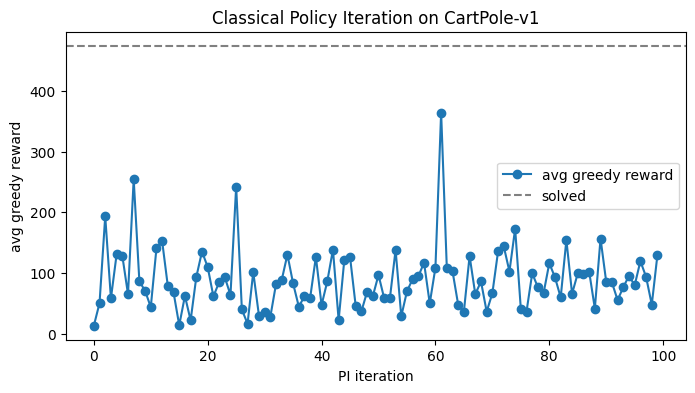

In [7]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, marker="o", label="avg greedy reward")
plt.axhline(cfg["training"]["solved_reward"], ls="--", c="grey", label="solved")
plt.xlabel("PI iteration"); plt.ylabel("avg greedy reward")
plt.title("Classical Policy Iteration on CartPole-v1")
plt.legend()
if logger:
    plt.savefig(logger.dir / "reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## Post-training analysis

`q_matrix_tabular` is the agent's own table — with 2 actions it is rank ≤ 2 by
construction, so the Hankel sweep (ran every iteration during training) is the
meaningful low-rank probe here.

Q-table


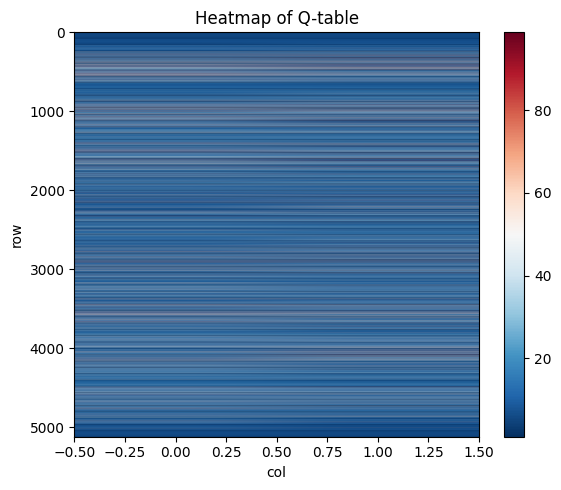

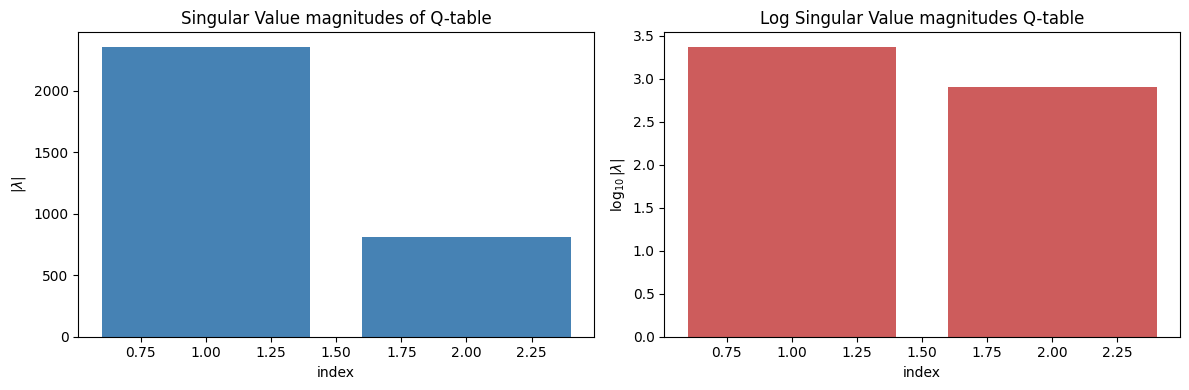

eff_rank: 2, stable_rank: 1.12, spikiness: 4.01, shape: (5120, 2), non-zero rows :5120, non-zero cols:2
top-r leverage spread: row min=1.797e-07 max=0.003573 (uniform 0.0001953) | col min=0.5 max=0.5 (uniform 0.5)
coherence score: row=18.29 col=1


In [8]:
methods = resolve_methods(cfg["analysis"].get("methods", []) + cfg["analysis"].get("post_methods", []))
for method, names in methods:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name, save_to=logger.figure_path(f"{name} heatmap") if logger else None)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name, save_to=logger.figure_path(name) if logger else None)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

In [9]:
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = build_env(cfg, render_mode="rgb_array")
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=cfg["experiment"]["seed"])
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)

/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


saved: videos/ep0-episode-0.mp4
